# Filtro anti-haters v3 — esperimento: negazioni e fastText

Il modello v2 (BiLSTM + Word2Vec) sbaglia di più sui commenti con negazioni (F1 0.69 contro 0.75) e non riconosce
le parole camuffate (`idi0t`, `f*ck`), perché **Word2Vec assegna un vettore fisso a ogni parola, indipendente dal contesto**,
e non ha vettori per le parole fuori vocabolario.

Due interventi, entrambi compatibili con il vincolo "niente Transformer":
1. **Marcatura delle negazioni**: le 3 parole che seguono una negazione (fino alla punteggiatura) diventano token distinti
   (`dont find offensive` → `dont neg_find neg_offensive`). Il modello vede esplicitamente che il senso è ribaltato.
2. **fastText addestrato sui commenti**: costruisce i vettori anche dai pezzi di parola (n-grammi di caratteri),
   quindi `idi0t` o `stupiddd` finiscono vicino a `idiot` e `stupid`.

**Nota sul preprocessing:** rispetto al v2 la pulizia elimina solo i numeri puri (IP, date) e non più le parole che contengono cifre,
così `idi0t` arriva al modello. La modifica vale per tutti e quattro gli esperimenti.

**Esperimento controllato:** stesso split, stessa architettura (BiLSTM 2×192, dropout 0.3), stessi pesi, stesse regole di
selezione del modello (`val_auc`) e soglie per classe. Cambiano solo embedding e preprocessing.

In [1]:
%pip install -q gensim

In [2]:
import os, re, json, string, shutil, gc, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

DATASET_DRIVE_PATH = '/content/drive/MyDrive/Filter_Toxic_Comments_dataset.csv'
WORK_DIR     = '/tmp/filtro_v3'
DATASET_PATH = os.path.join(WORK_DIR, 'dataset.csv')
DRIVE_FOLDER = '/content/drive/MyDrive/modelli_addestrati/filtro_anti_haters_v3'
SAMPLE_FRAC  = 1.0

LABEL_COLUMNS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
MAX_FEATURES, MAX_LEN = 20000, 200
LSTM_UNITS, DROPOUT   = 192, 0.3            # migliori iperparametri del tuning v2
BATCH_SIZE, EPOCHS, PATIENCE = 32, 6, 2     # nel v2 la val_auc migliore arrivava entro la 3a epoca
NEG_SCOPE     = 3                           # parole marcate dopo una negazione
FASTTEXT_EPOCHS = 5
RANDOM_STATE  = 42
USE_WORD2VEC  = True

EXPERIMENTS = [
    # nome,                         embedding,   negazioni marcate
    ('A · Word2Vec (come v2)',  'word2vec',  False),
    ('B · Word2Vec + negazioni',    'word2vec',  True),
    ('C · fastText',                'fasttext',  False),
    ('D · fastText + negazioni',    'fasttext',  True),
]

os.makedirs(WORK_DIR, exist_ok=True)
try:
    from google.colab import drive
    IN_COLAB = True
    if not os.path.exists('/content/drive/MyDrive'):
        drive.mount('/content/drive')
except ImportError:
    IN_COLAB = False
print('GPU:', tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Dati e preprocessing

In [3]:
if not os.path.exists(DATASET_PATH):
    shutil.copy(DATASET_DRIVE_PATH, DATASET_PATH)
df = pd.read_csv(DATASET_PATH, on_bad_lines='skip').dropna(subset=['comment_text']).reset_index(drop=True)
if SAMPLE_FRAC < 1.0:
    df = df.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE).reset_index(drop=True)

_PUNCT_NO_APOS = string.punctuation.replace("'", "")
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[\r\n\t]+', ' ', text)
    text = re.sub(r"[’`']", '', text)
    text = re.sub(r'[%s]' % re.escape(_PUNCT_NO_APOS), ' ', text)
    text = re.sub(r'\b\d+\b', ' ', text)      # solo numeri puri (IP, date): 'idi0t' resta, v2 lo eliminava
    return re.sub(r'\s+', ' ', text).strip()

NEGATIONS = {'not', 'no', 'never', 'nothing', 'nobody', 'none', 'nor', 'without', 'dont', 'doesnt', 'didnt',
             'isnt', 'arent', 'wasnt', 'werent', 'havent', 'hasnt', 'hadnt', 'cant', 'cannot', 'couldnt',
             'wont', 'wouldnt', 'shouldnt', 'aint'}
_CLAUSE_SPLIT = re.compile(r'[.!?;:,()\[\]\n]+')

def mark_negations(raw, scope=NEG_SCOPE):
    # La negazione vale fino alla punteggiatura successiva, per al massimo `scope` parole
    out = []
    for clause in _CLAUSE_SPLIT.split(str(raw)):
        left = 0
        for w in clean_text(clause).split():
            if w in NEGATIONS:
                out.append(w); left = scope
            elif left > 0:
                out.append('neg_' + w); left -= 1
            else:
                out.append(w)
    return ' '.join(out)

assert mark_negations("I don't find this offensive.") == 'i dont neg_find neg_this neg_offensive'
assert mark_negations("Not bad, you idiot!") == 'not neg_bad you idiot'
assert mark_negations("I know it") == 'i know it'          # 'no' dentro 'know' non conta
assert clean_text('retired now.89.205.38.27 you idi0t') == 'retired now you idi0t'

t0 = time.time()
texts = {False: df['comment_text'].apply(clean_text),
         True:  df['comment_text'].apply(mark_negations)}
print(f'Preprocessing: {time.time()-t0:.0f}s')
for i in [3, 9]:
    print('\nOriginale:', df['comment_text'].iloc[i][:160].replace('\n', ' '))
    print('Marcato:  ', texts[True].iloc[i][:160])

Preprocessing: 55s

Originale: " More I can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of ""types of accidents""  -I
Marcato:   more i cant neg_make neg_any neg_real suggestions on improvement i wondered if the section statistics should be later on or a subsection of types of accidents i

Originale: alignment on this subject and which are contrary to those of DuLithgow
Marcato:   alignment on this subject and which are contrary to those of dulithgow


In [4]:
# Split unico per tutti gli esperimenti (80/10/10), sugli indici
idx_train, idx_temp = train_test_split(df.index, test_size=0.2, random_state=RANDOM_STATE)
idx_val, idx_test   = train_test_split(idx_temp, test_size=0.5, random_state=RANDOM_STATE)
Y = df[LABEL_COLUMNS].values.astype('float32')
y_train, y_val, y_test = Y[idx_train], Y[idx_val], Y[idx_test]

# Commenti del test set con negazione (definizione unica per tutti gli esperimenti)
neg_re = re.compile(r'\b(?:' + '|'.join(NEGATIONS) + r')\b')
has_neg_test = texts[False].loc[idx_test].str.contains(neg_re).values
print(f'Test: {len(idx_test):,} commenti, di cui con negazione {has_neg_test.mean():.1%}')

# Pesi dei campioni (come v2)
sample_weights = np.ones(len(y_train))
for j in range(len(LABEL_COLUMNS)):
    pos = y_train[:, j].sum(); neg = len(y_train) - pos
    sample_weights[y_train[:, j] == 1] += neg / pos - 1.0
sample_weights /= sample_weights.mean()

Test: 15,958 commenti, di cui con negazione 54.0%


## 2. Tokenizer ed embedding
- **Word2Vec** (`word2vec-google-news-300`): per i token marcati `neg_x` si parte dal vettore di `x`; il modello impara poi a differenziarli.
- **fastText**: addestrato (gensim) sui soli commenti del training set, 300 dimensioni, n-grammi di caratteri da 3 a 6.
  Ogni parola ha un vettore, anche se rara o storpiata.

In [5]:
tokenizers, sequences = {}, {}
for neg in (False, True):
    # filters='': il testo è già pulito, e il filtro di default toglierebbe '_' spezzando i token neg_x
    tok = Tokenizer(num_words=MAX_FEATURES, oov_token='<unk>', filters='')
    tok.fit_on_texts(texts[neg].loc[idx_train])
    tokenizers[neg] = tok
    pad = lambda idx: pad_sequences(tok.texts_to_sequences(texts[neg].loc[idx]), maxlen=MAX_LEN,
                                    padding='post', truncating='post')
    sequences[neg] = (pad(idx_train), pad(idx_val), pad(idx_test))
    n_neg_tokens = sum(1 for w, i in tok.word_index.items() if i <= MAX_FEATURES and w.startswith('neg_'))
    print(f'negazioni={neg}: token "neg_" nel vocabolario = {n_neg_tokens:,}')

negazioni=False: token "neg_" nel vocabolario = 0
negazioni=True: token "neg_" nel vocabolario = 2,199


In [6]:
# Le matrici di embedding vengono salvate su Drive: se la sessione si interrompe non si ricalcolano (~25 min)
os.makedirs(DRIVE_FOLDER if IN_COLAB else WORK_DIR, exist_ok=True)
CACHE_DIR = DRIVE_FOLDER if IN_COLAB else WORK_DIR
EMB_CACHE = os.path.join(CACHE_DIR, 'embeddings_cache.npz')
rng = np.random.default_rng(RANDOM_STATE)
def random_matrix(dim=300):
    m = rng.normal(0, 0.05, (MAX_FEATURES + 1, dim)).astype('float32'); m[0] = 0
    return m

embeddings = {}
if os.path.exists(EMB_CACHE):
    cache = np.load(EMB_CACHE, allow_pickle=True)
    embeddings = {(k.split('|')[0], k.split('|')[1] == 'neg'): cache[k] for k in cache.files if '|' in k}
    neighbours_idi0t = [str(w) for w in cache['neighbours_idi0t']]
    print('Embedding caricati dalla cache:', EMB_CACHE)
else:
    # --- Word2Vec ---
    w2v = None
    if USE_WORD2VEC:
        try:
            import gensim.downloader as api
            w2v = api.load('word2vec-google-news-300')
        except Exception as e:
            print('Word2Vec non disponibile:', e)
    for neg in (False, True):
        m, found = random_matrix(), 0
        if w2v is not None:
            for w, i in tokenizers[neg].word_index.items():
                if i > MAX_FEATURES: continue
                base = w[4:] if w.startswith('neg_') else w
                if base in w2v.key_to_index:
                    m[i] = w2v[base]; found += 1
        embeddings[('word2vec', neg)] = m
        print(f'Copertura Word2Vec (negazioni={neg}): {found / MAX_FEATURES:.1%}')
    del w2v; gc.collect()

    # --- fastText addestrato sul training set ---
    # bucket ridotto (500k invece di 2M n-grammi): ~0.6 GB di RAM invece di ~2.4 GB per modello
    from gensim.models import FastText
    for neg in (False, True):
        t0 = time.time()
        corpus = [t.split() for t in texts[neg].loc[idx_train]]
        ft = FastText(vector_size=300, window=5, min_count=3, min_n=3, max_n=6, sg=1, bucket=500_000,
                      epochs=FASTTEXT_EPOCHS, workers=os.cpu_count(), seed=RANDOM_STATE)
        ft.build_vocab(corpus)
        ft.train(corpus, total_examples=len(corpus), epochs=FASTTEXT_EPOCHS)
        m = random_matrix()
        for w, i in tokenizers[neg].word_index.items():
            if i <= MAX_FEATURES:
                m[i] = ft.wv[w]                     # sempre disponibile grazie agli n-grammi
        embeddings[('fasttext', neg)] = m
        if not neg:
            neighbours_idi0t = [w for w, _ in ft.wv.most_similar('idi0t', topn=5)]
        print(f'fastText negazioni={neg}: {time.time()-t0:.0f}s')
        del corpus, ft; gc.collect()
    np.savez(EMB_CACHE, neighbours_idi0t=np.array(neighbours_idi0t),
             **{f'{e}|{"neg" if n else "plain"}': m for (e, n), m in embeddings.items()})

print('\nVicini di "idi0t" secondo fastText (parola assente da Word2Vec):', neighbours_idi0t)

Copertura Word2Vec (negazioni=False): 89.4%
Copertura Word2Vec (negazioni=True): 91.3%
fastText negazioni=False: 682s
fastText negazioni=True: 702s

Vicini di "idi0t" secondo fastText (parola assente da Word2Vec): ['idiom', 'idiocy', 'idioms', 'idiots', 'idiotic']


## 3. Addestramento dei quattro modelli
Per ogni esperimento: addestramento con checkpoint sulla `val_auc`, soglie per classe scelte sul validation set, metriche sul test set.

In [7]:
def build_model(embedding_matrix):
    inputs = tf.keras.layers.Input(shape=(MAX_LEN,))
    x = tf.keras.layers.Embedding(MAX_FEATURES + 1, embedding_matrix.shape[1],
                                  embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix))(inputs)
    x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(LSTM_UNITS, return_sequences=True))(x)
    x = tf.keras.layers.Dropout(DROPOUT)(x)
    x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(LSTM_UNITS))(x)
    x = tf.keras.layers.Dropout(DROPOUT)(x)
    outputs = tf.keras.layers.Dense(len(LABEL_COLUMNS), activation='sigmoid')(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile('adam', 'binary_crossentropy',
                  metrics=[tf.keras.metrics.AUC(multi_label=True, num_labels=len(LABEL_COLUMNS), name='auc')])
    return model

def tune_thresholds(y_true, y_proba, grid=np.round(np.arange(0.05, 0.96, 0.01), 2)):
    return np.array([grid[int(np.argmax([f1_score(y_true[:, j], y_proba[:, j] >= t, zero_division=0) for t in grid]))]
                     for j in range(y_true.shape[1])])

# Ogni esperimento concluso viene salvato su Drive (modello + riga di risultati):
# se la sessione cade, rieseguendo la cella si riparte dal primo esperimento mancante.
RESULTS_CSV = os.path.join(CACHE_DIR, 'risultati_esperimenti.csv')
results = pd.read_csv(RESULTS_CSV).to_dict('records') if os.path.exists(RESULTS_CSV) else []
model_paths = {}
for name, emb, neg in EXPERIMENTS:
    path = os.path.join(CACHE_DIR, f'model_{emb}_{"neg" if neg else "plain"}.keras')
    model_paths[name] = (path, neg)
    if name in {r['esperimento'] for r in results} and os.path.exists(path):
        print(f'{name}: già completato, salto'); continue
    print(f'\n===== {name} =====')
    tf.keras.backend.clear_session(); gc.collect(); tf.keras.utils.set_random_seed(RANDOM_STATE)
    x_tr, x_va, x_te = sequences[neg]
    local_path = os.path.join(WORK_DIR, os.path.basename(path))
    model = build_model(embeddings[(emb, neg)])
    t0 = time.time()
    hist = model.fit(x_tr, y_train, batch_size=BATCH_SIZE, epochs=EPOCHS, validation_data=(x_va, y_val),
                     sample_weight=sample_weights, verbose=2, callbacks=[
                         EarlyStopping(monitor='val_auc', mode='max', patience=PATIENCE, restore_best_weights=True),
                         ModelCheckpoint(local_path, monitor='val_auc', mode='max', save_best_only=True),
                         ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.2, patience=1, min_lr=1e-5)])
    model = tf.keras.models.load_model(local_path)
    thr = tune_thresholds(y_val, model.predict(x_va, batch_size=512, verbose=0))
    p = model.predict(x_te, batch_size=512, verbose=0)
    pred = (p >= thr).astype(int); yt = y_test.astype(int)
    row = {'esperimento': name,
           'ROC AUC': np.mean([roc_auc_score(yt[:, j], p[:, j]) for j in range(yt.shape[1])]),
           'F1 micro': f1_score(yt, pred, average='micro', zero_division=0),
           'F1 macro': f1_score(yt, pred, average='macro', zero_division=0),
           'F1 con negazione': f1_score(yt[has_neg_test], pred[has_neg_test], average='micro', zero_division=0),
           'F1 senza negazione': f1_score(yt[~has_neg_test], pred[~has_neg_test], average='micro', zero_division=0),
           'epoca migliore': int(np.argmax(hist.history['val_auc'])) + 1,
           'minuti': (time.time() - t0) / 60,
           'soglie': json.dumps(dict(zip(LABEL_COLUMNS, map(float, thr))))}
    row.update({f'F1 {l}': f1_score(yt[:, j], pred[:, j], zero_division=0) for j, l in enumerate(LABEL_COLUMNS)})
    results.append(row)
    if local_path != path: shutil.copy(local_path, path)
    pd.DataFrame(results).to_csv(RESULTS_CSV, index=False)
    print({k: round(v, 4) if isinstance(v, float) else v for k, v in row.items() if k != 'soglie'})
    del model, hist, p; gc.collect()


===== A · Word2Vec (come v2) =====
Epoch 1/6
3990/3990 - 237s - 59ms/step - auc: 0.9135 - loss: 0.4081 - val_auc: 0.9738 - val_loss: 0.2818 - learning_rate: 0.0010
Epoch 2/6
3990/3990 - 231s - 58ms/step - auc: 0.9725 - loss: 0.3080 - val_auc: 0.9792 - val_loss: 0.1168 - learning_rate: 0.0010
Epoch 3/6
3990/3990 - 232s - 58ms/step - auc: 0.9835 - loss: 0.2622 - val_auc: 0.9800 - val_loss: 0.0989 - learning_rate: 0.0010
Epoch 4/6
3990/3990 - 219s - 55ms/step - auc: 0.9872 - loss: 0.2306 - val_auc: 0.9772 - val_loss: 0.0816 - learning_rate: 0.0010
Epoch 5/6
3990/3990 - 219s - 55ms/step - auc: 0.9915 - loss: 0.1826 - val_auc: 0.9726 - val_loss: 0.0699 - learning_rate: 2.0000e-04
{'esperimento': 'A · Word2Vec (come v2)', 'ROC AUC': np.float64(0.9803), 'F1 micro': 0.7364, 'F1 macro': 0.6127, 'F1 con negazione': 0.7, 'F1 senza negazione': 0.7604, 'epoca migliore': 3, 'minuti': 19.3102, 'F1 toxic': 0.7735, 'F1 severe_toxic': 0.5125, 'F1 obscene': 0.8101, 'F1 threat': 0.4048, 'F1 insult': 0.72

## 4. Confronto

,ROC AUC,F1 micro,F1 macro,F1 con negazione,F1 senza negazione,epoca migliore,minuti
esperimento,,,,,,,
A · Word2Vec (come v2),0.980,0.736,0.613,0.700,0.760,3,19
B · Word2Vec + negazioni,0.980,0.723,0.609,0.695,0.741,3,19
C · fastText,0.979,0.724,0.598,0.687,0.748,3,19
D · fastText + negazioni,0.980,0.730,0.607,0.693,0.752,3,19


,F1 toxic,F1 severe_toxic,F1 obscene,F1 threat,F1 insult,F1 identity_hate
esperimento,,,,,,
A · Word2Vec (come v2),0.774,0.512,0.810,0.405,0.730,0.445
B · Word2Vec + negazioni,0.765,0.527,0.792,0.467,0.710,0.392
C · fastText,0.766,0.521,0.806,0.349,0.712,0.433
D · fastText + negazioni,0.770,0.546,0.797,0.375,0.714,0.436


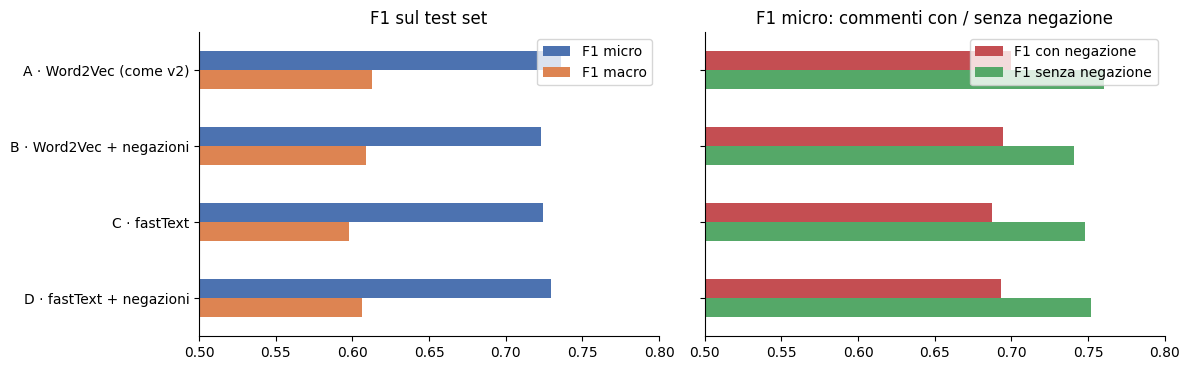

In [8]:
res = pd.DataFrame(results).set_index('esperimento')
main_cols = ['ROC AUC', 'F1 micro', 'F1 macro', 'F1 con negazione', 'F1 senza negazione', 'epoca migliore', 'minuti']
display(res[main_cols].style.format('{:.3f}', subset=main_cols[:5]).format('{:.0f}', subset=main_cols[5:])
        .highlight_max(subset=main_cols[:5], color='#2e7d32'))
display(res[[f'F1 {l}' for l in LABEL_COLUMNS]].style.format('{:.3f}').highlight_max(color='#2e7d32'))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
res[['F1 micro', 'F1 macro']].plot.barh(ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_xlim(0.5, 0.8); axes[0].set_title('F1 sul test set'); axes[0].invert_yaxis()
res[['F1 con negazione', 'F1 senza negazione']].plot.barh(ax=axes[1], color=['#C44E52', '#55A868'])
axes[1].set_xlim(0.5, 0.8); axes[1].set_title('F1 micro: commenti con / senza negazione'); axes[1].invert_yaxis()
axes[1].set_yticklabels([])
for ax in axes:
    ax.set_ylabel(''); sns.despine(ax=ax)
plt.tight_layout(); plt.show()

### Robustezza: negazioni e parole camuffate
Frasi scritte a mano per testare i due punti deboli di Word2Vec.

In [10]:
probe = [
    "I don't find this offensive at all.",
    "This is not stupid, it is a good idea.",
    "You are not an idiot, you just made a mistake.",
    "You are an idiot.",
    "You are an idi0t.",
    "you are such a stupiddd moron",
    "f*ck you and your edits",
    "Thanks for fixing the references.",
]
def predict_toxic(model, tok, neg, thr, sentences):
    prep = mark_negations if neg else clean_text
    seq = pad_sequences(tok.texts_to_sequences([prep(s) for s in sentences]), maxlen=MAX_LEN, padding='post', truncating='post')
    return model.predict(seq, verbose=0)[:, 0]          # probabilità della classe 'toxic'

probe_df = pd.DataFrame({'frase': probe})
for name, (path, neg) in model_paths.items():
    tf.keras.backend.clear_session()
    model = tf.keras.models.load_model(path)
    probe_df[name.split(' · ')[0]] = predict_toxic(model, tokenizers[neg], neg, None, probe)
    del model; gc.collect()
display(probe_df.style.format('{:.2f}', subset=probe_df.columns[1:])
        .background_gradient(subset=probe_df.columns[1:], cmap='Reds', vmin=0, vmax=1))

,frase,A,B,C,D
0,I don't find this offensive at all.,0.35,0.11,0.41,0.14
1,"This is not stupid, it is a good idea.",0.94,0.92,0.92,0.94
2,"You are not an idiot, you just made a mistake.",0.98,0.95,0.96,0.98
3,You are an idiot.,0.99,0.99,0.99,0.99
4,You are an idi0t.,0.94,0.96,0.95,0.97
5,you are such a stupiddd moron,0.99,0.99,0.99,0.99
6,f*ck you and your edits,0.99,1.00,0.99,0.99
7,Thanks for fixing the references.,0.02,0.02,0.02,0.01


In [11]:
# Modello migliore (per F1 macro) pronto per l'inferenza: modello, tokenizer e configurazione
import pickle
best = res['F1 macro'].idxmax()
path, neg = model_paths[best]
out = os.path.join(CACHE_DIR, 'migliore'); os.makedirs(out, exist_ok=True)
shutil.copy(path, os.path.join(out, 'best_model.keras'))
with open(os.path.join(out, 'tokenizer.pickle'), 'wb') as f:
    pickle.dump(tokenizers[neg], f)
with open(os.path.join(out, 'config.json'), 'w') as f:
    json.dump({'esperimento': best, 'negation_marking': bool(neg), 'NEG_SCOPE': NEG_SCOPE, 'MAX_LEN': MAX_LEN,
               'LABEL_COLUMNS': LABEL_COLUMNS, 'thresholds': json.loads(res.loc[best, 'soglie'])}, f, indent=2)
print('Modello migliore:', best, '→', out)

Modello migliore: A · Word2Vec (come v2) → /content/drive/MyDrive/modelli_addestrati/filtro_anti_haters_v3/migliore


## 5. Conclusioni

**Risultato: nessuno dei due interventi migliora in modo significativo il modello.** Le differenze tra i quattro esperimenti
(F1 micro 0.723–0.736, F1 macro 0.598–0.613, ROC AUC 0.979–0.980) sono dell'ordine di un punto percentuale:
la stessa variabilità che si ottiene cambiando il seed. Il divario tra commenti con e senza negazione (~5 punti di F1) resta in tutti i casi.

Perché:
- **Marcatura delle negazioni:** crea ~2.200 nuovi token `neg_x`, ciascuno con pochi esempi. La BiLSTM bidirezionale
  vede già la negazione nella sequenza: la marcatura aggiunge poca informazione e frammenta il vocabolario.
- **fastText sui soli commenti:** 127k commenti sono pochi per imparare buone rappresentazioni; i vicini di `idi0t` sono
  `idiom`, `idiocy`, `idiots`: somiglianza di **forma** (n-grammi di caratteri), non di significato.
  Word2Vec, addestrato su ~100 miliardi di parole, resta una base semantica migliore.

**Test sulle frasi:** la marcatura aiuta sulla negazione "morbida" (*I don't find this offensive*: probabilità toxic
0.35 → 0.11), ma non quando la frase contiene un insulto esplicito (*You are not an idiot*: 0.98 in tutti i modelli):
la parola forte domina. `idi0t` e `stupiddd` sono riconosciuti da tutti i modelli: la frase *You are an …* basta al contesto.

**Scelta finale:** si mantiene l'architettura **A (Word2Vec)**, con la nuova pulizia che conserva le parole con cifre
(F1 micro 0.736 contro 0.726 del v2). Per superare davvero il limite delle negazioni serve un modello contestuale
(Transformer, es. DistilBERT), escluso dal vincolo di progetto: è il naturale passo successivo.
